Question 8


A.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

X = 2 * np.random.rand(100, 1)
y = 5 + 3 * X + np.random.randn(100, 1)
i = np.random.permutation(100)
train_idx, test_idx = i[:80], i[80:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print("Traning data")
print(X_train.T)
print(y_train.T)
print("Test data")
print(X_test.T)
print(y_test.T)


Traning data
[[0.54310428 1.71604069 1.86957313 0.8605942  1.81667501 0.51970351
  0.50063268 1.11868615 1.47546276 0.66860311 0.71415101 0.3012926
  1.65815431 0.73913003 1.48738895 1.97243057 1.76115464 0.22579694
  0.1155573  1.72831715 0.04640185 0.24989518 0.51359217 0.69736666
  1.6073634  0.43219559 1.93989115 1.30249488 1.96594876 0.03225339
  1.98188031 0.86824831 1.03995259 1.17065328 1.35463785 0.6334726
  0.18761672 0.700976   1.4314861  1.83004927 0.55077895 1.37261454
  0.08879827 0.62715649 1.42966489 1.53352749 1.57624291 1.68900455
  1.43383391 0.88491974 0.97681796 0.97574373 1.6385181  1.4440305
  0.93056583 1.65327854 1.9770372  1.38926327 1.01028045 0.719474
  0.96483329 1.8052158  1.69327944 0.48536762 0.91905115 0.85090578
  0.65628499 0.5201056  1.5877847  0.60897326 0.16081867 1.99918428
  1.56849538 0.97891855 0.23083226 1.0727585  1.55567367 0.18202906
  0.01406079 0.68632429]]
[[ 6.00743714 11.09589995 12.77390296  7.8608587  10.58986238  5.35466555
   7.546

B.


In [18]:
def solve_regression(x_data, y_data, degree):
    n = len(x_data)
    m = degree + 1
    A = [[0] * m for _ in range(m)]
    B = [0] * m

    for i in range(m):
        for j in range(m):
            A[i][j] = sum(x**(i + j) for x in x_data)
        B[i] = sum(y * (x**i) for x, y in zip(x_data, y_data))

    for i in range(m):
        pivot = A[i][i]
        for j in range(i + 1, m):
            factor = A[j][i] / pivot
            for k in range(i, m):
                A[j][k] -= factor * A[i][k]
            B[j] -= factor * B[i]

    w = [0] * m
    for i in range(m - 1, -1, -1):
        w[i] = B[i] / A[i][i]
        for j in range(i - 1, -1, -1):
            B[j] -= A[j][i] * w[i]
    return w

def predict(x, weights):
    return sum(w * (x**i) for i, w in enumerate(weights))



C.

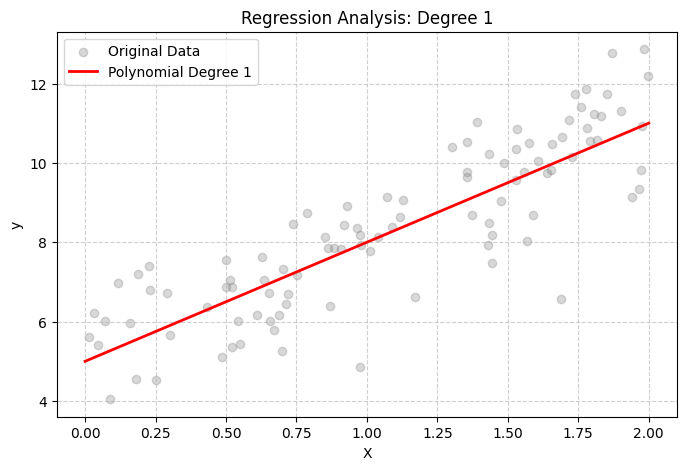

In [19]:
all_degrees = [1]
colors = {1: 'red', 2: 'green', 3: 'orange'}

for d in all_degrees:
    plt.figure(figsize=(8, 5))
    th = solve_regression(X_train.flatten(), y_train.flatten(), d)
    y_p = predict(X_test.flatten(), th)

    X_line = np.linspace(0, 2, 100).reshape(-1, 1)
    y_line = predict(X_line.flatten(), th)


    plt.scatter(X, y, color='gray', alpha=0.3, label='Original Data')
    plt.plot(X_line, y_line, label=f'Polynomial Degree {d}', color=colors[d], linewidth=2)

    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Regression Analysis: Degree {d}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()


D.

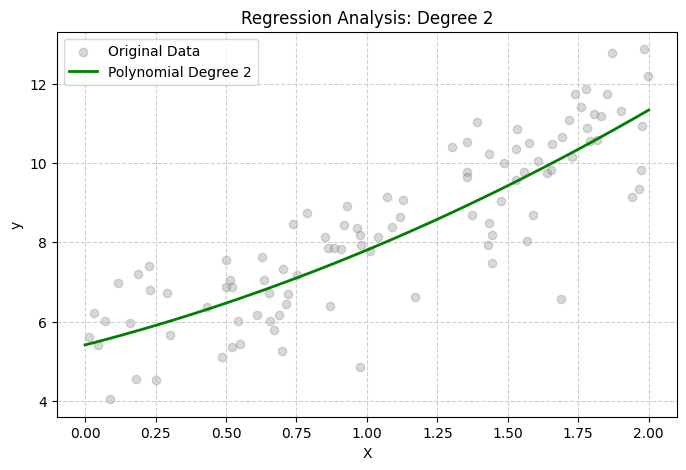

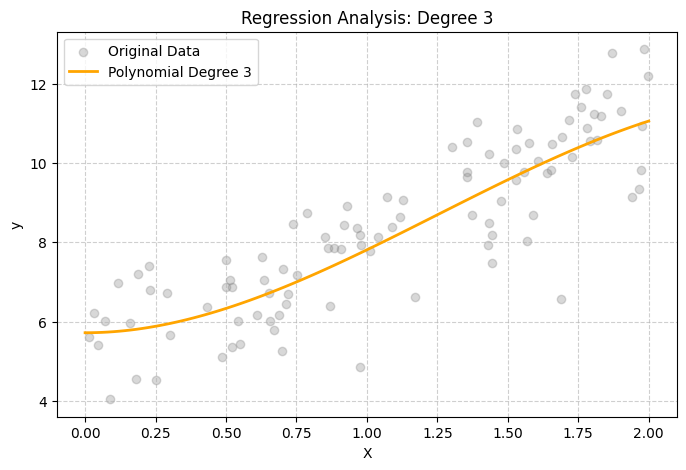

In [20]:
all_degrees = [2, 3]
colors = {1: 'red', 2: 'green', 3: 'orange'}

for d in all_degrees:
    plt.figure(figsize=(8, 5))
    th = solve_regression(X_train.flatten(), y_train.flatten(), d)
    y_p = predict(X_test.flatten(), th)

    X_line = np.linspace(0, 2, 100).reshape(-1, 1)
    y_line = predict(X_line.flatten(), th)

    plot_X = np.vstack((X_train, X_test))
    plot_y = np.vstack((y_train, y_test))

    plt.scatter(plot_X, plot_y, color='gray', alpha=0.3, label='Original Data')
    plt.plot(X_line, y_line, label=f'Polynomial Degree {d}', color=colors[d], linewidth=2)

    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Regression Analysis: Degree {d}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()


Question 9

In [23]:
import pandas as pd
import numpy as np
df = pd.read_csv('A2_P2_ae609303-e3ee-4dc3-85f0-d40fdde4ae63.csv')
X1 = df['Feature 1'].values
X2 = df['Feature 2'].values
y = df['Output'].values
m = len(y)
mean1, std1 = np.mean(X1), np.std(X1)
mean2, std2 = np.mean(X2), np.std(X2)

X1_s = (X1 - mean1) / std1
X2_s = (X2 - mean2) / std2

w1, w2, b = 0.0, 0.0, 0.0
learning_rate = 0.1
epochs = 1000
for i in range(epochs):

    z = w1 * X1_s + w2 * X2_s + b

    pred = 1 / (1 + np.exp(-z))

    errors = pred - y
    dw1 = (1 / m) * np.sum(errors * X1_s)
    dw2 = (1 / m) * np.sum(errors * X2_s)
    db = (1 / m) * np.sum(errors)

    w1 -= learning_rate * dw1
    w2 -= learning_rate * dw2
    b -= learning_rate * db

w1_f = w1 / std1
w2_f = w2 / std2
b_f = b - (w1 * mean1 / std1) - (w2 * mean2 / std2)

print(f"Final Weights: w1 = {w1_f:.6f}, w2 = {w2_f:.6f}")
print(f"Final Bias (Intercept): b = {b_f:.6f}")
print(f"\nDecision Boundary Equation:")
print(f"{w1_f:.6f} * (Feature 1) + {w2_f:.6f} * (Feature 2) + {b_f:.6f} = 0")

Final Weights: w1 = 1.080729, w2 = -0.000192
Final Bias (Intercept): b = 5.803363

Decision Boundary Equation:
1.080729 * (Feature 1) + -0.000192 * (Feature 2) + 5.803363 = 0


In [22]:
from google.colab import files

print("Please upload the file 'A2_P2_ae609303-e3ee-4dc3-85f0-d40fdde4ae63.csv'")
files.upload()

Please upload the file 'A2_P2_ae609303-e3ee-4dc3-85f0-d40fdde4ae63.csv'


Saving A2_P2_ae609303-e3ee-4dc3-85f0-d40fdde4ae63.csv to A2_P2_ae609303-e3ee-4dc3-85f0-d40fdde4ae63.csv


{'A2_P2_ae609303-e3ee-4dc3-85f0-d40fdde4ae63.csv': b'Samples,Feature 1,Feature 2,Output\r\n1,0.7,48000,1\r\n2,1.9,48000,0\r\n3,2.5,60000,1\r\n4,4.2,63000,0\r\n5,6,76000,0\r\n6,6.5,69000,0\r\n7,7.5,76000,0\r\n8,8.1,88000,0\r\n9,8.7,83000,1\r\n10,10,83000,1\r\n11,0.8,43000,0\r\n12,1.8,60000,0\r\n13,10,79000,1\r\n14,6.1,76000,0\r\n15,1.4,50000,0\r\n16,9.1,92000,0\r\n17,5.8,75000,0\r\n18,5.2,69000,0\r\n19,1,56000,0\r\n20,6,67000,0\r\n21,4.9,74000,0\r\n22,6.4,63000,1\r\n23,6.2,82000,0\r\n24,3.3,58000,0\r\n25,9.3,90000,1\r\n26,5.5,57000,1\r\n27,9.1,102000,0\r\n28,2.4,54000,0\r\n29,8.2,65000,1\r\n30,5.3,82000,0\r\n31,9.8,107000,0\r\n32,1.8,64000,0\r\n33,0.6,46000,1\r\n34,0.8,48000,0\r\n35,8.6,84000,1\r\n36,0.6,45000,0\r\n37,0.5,30000,1\r\n38,7.3,89000,0\r\n39,2.5,48000,1\r\n40,5.6,76000,0\r\n41,7.4,77000,0\r\n42,2.7,56000,0\r\n43,0.7,48000,0\r\n44,1.2,42000,0\r\n45,0.2,32000,1\r\n46,4.7,56000,1\r\n47,2.8,44000,1\r\n48,7.6,78000,0\r\n49,1.1,63000,0\r\n50,8,79000,1\r\n51,2.7,56000,0\r\n52,6,520

Question 10

Saving A2_P3_744f5041-4369-44f9-be92-7dacb5a520d7.csv to A2_P3_744f5041-4369-44f9-be92-7dacb5a520d7 (5).csv
MSE -> Normal: 3.0888, Batch: 3.0888, Stochastic: 3.1962


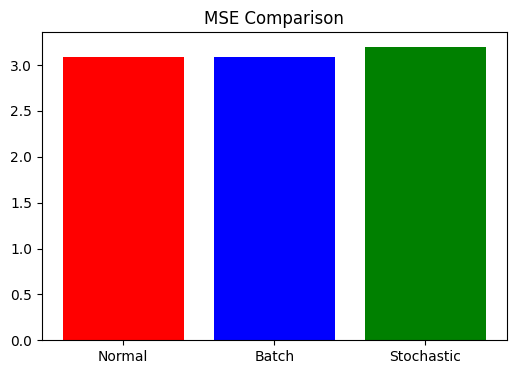

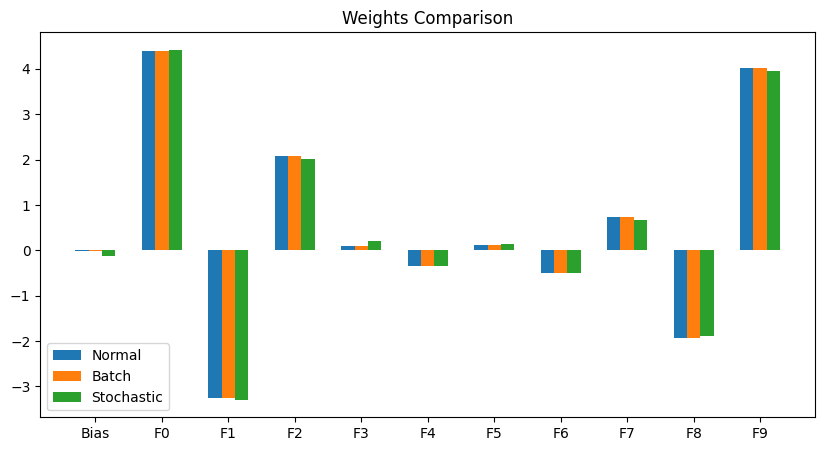

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os
from google.colab import files
files.upload()
file_name = 'A2_P3_744f5041-4369-44f9-be92-7dacb5a520d7.csv'

if not os.path.exists(file_name):
    print(f"Please upload the file '{file_name}'")
    uploaded = files.upload()

df = pd.read_csv(file_name)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

m, s = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - m) / s
X_test = (X_test - m) / s

X_tr = np.c_[np.ones(len(X_train)), X_train]
X_te = np.c_[np.ones(len(X_test)), X_test]

w_norm = np.linalg.inv(X_tr.T @ X_tr) @ X_tr.T @ y_train
mse_norm = np.mean((y_test - X_te @ w_norm)**2)

w_bgd = np.zeros((X_tr.shape[1], 1))
for _ in range(1000):
    grad = (1/len(X_tr)) * X_tr.T @ (X_tr @ w_bgd - y_train)
    w_bgd -= 0.1 * grad
mse_bgd = np.mean((y_test - X_te @ w_bgd)**2)

w_sgd = np.zeros((X_tr.shape[1], 1))
for _ in range(50):
    for i in range(len(X_tr)):
        row, target = X_tr[i:i+1], y_train[i:i+1]
        grad = row.T @ (row @ w_sgd - target)
        w_sgd -= 0.01 * grad
mse_sgd = np.mean((y_test - X_te @ w_sgd)**2)

plt.figure(figsize=(6, 4))
plt.bar(['Normal', 'Batch', 'Stochastic'], [mse_norm, mse_bgd, mse_sgd], color=['red', 'blue', 'green'])
plt.title('MSE Comparison')

plt.figure(figsize=(10, 5))
x_axis = np.arange(len(w_norm))
plt.bar(x_axis - 0.2, w_norm.flatten(), 0.2, label='Normal')
plt.bar(x_axis, w_bgd.flatten(), 0.2, label='Batch')
plt.bar(x_axis + 0.2, w_sgd.flatten(), 0.2, label='Stochastic')
plt.xticks(x_axis, ['Bias'] + [f'F{i}' for i in range(10)])
plt.legend()
plt.title('Weights Comparison')

print(f"MSE -> Normal: {mse_norm:.4f}, Batch: {mse_bgd:.4f}, Stochastic: {mse_sgd:.4f}")